#Install dependencies



In [ ]:
# Force-reinstall compatible versions of numpy, mediapipe, and opencv
!pip install --upgrade --force-reinstall numpy==1.23.5 opencv-python-headless==4.8.0.76 mediapipe==0.10.0


  Using cached numpy-1.23.5-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (2.3 kB)
  Using cached opencv_python_headless-4.8.0.76-cp37-abi3-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (19 kB)
ERROR: Ignored the following versions that require a different python version: 1.21.2 Requires-Python >=3.7,<3.11; 1.21.3 Requires-Python >=3.7,<3.11; 1.21.4 Requires-Python >=3.7,<3.11; 1.21.5 Requires-Python >=3.7,<3.11; 1.21.6 Requires-Python >=3.7,<3.11
ERROR: Could not find a version that satisfies the requirement mediapipe==0.10.0 (from versions: 0.10.5, 0.10.7, 0.10.8, 0.10.9, 0.10.10, 0.10.11, 0.10.13, 0.10.14, 0.10.15, 0.10.18, 0.10.20, 0.10.21)
ERROR: No matching distribution found for mediapipe==0.10.0


In [ ]:
#Import libraries
import os
os.system('pip install mediapipe > /dev/null')
import cv2
import mediapipe as mp
import numpy as np
from tqdm import tqdm
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

In [ ]:
!pip install torchsummary


#Mount to google drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


#Dataset Path

In [ ]:
dataset_path = '/content/drive/My Drive/hgr/hagriddataset'


#Extracting hand landmarks using mediapipe

In [ ]:
import cv2
import mediapipe as mp
import numpy as np
import os
from tqdm import tqdm

mp_hands = mp.solutions.hands
hands = mp_hands.Hands(static_image_mode=True)
mp_drawing = mp.solutions.drawing_utils

X = []
y = []

dataset_path = '/content/drive/MyDrive/hgr/hagriddataset/hagrid-sample-30k-384p/hagrid_30k'
classes = sorted(os.listdir(dataset_path))

for label in classes:
    class_dir = os.path.join(dataset_path, label)
    for img_file in tqdm(os.listdir(class_dir), desc=f"Processing {label}"):
        img_path = os.path.join(class_dir, img_file)
        img = cv2.imread(img_path)
        if img is None:
            continue
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        result = hands.process(img_rgb)
        if result.multi_hand_landmarks:
            landmarks = result.multi_hand_landmarks[0].landmark
            coords = np.array([[lm.x, lm.y, lm.z] for lm in landmarks]).flatten()
            X.append(coords)
            y.append(label)

hands.close()

X = np.array(X)
y = np.array(y)

np.save('X_landmarks.npy', X)
np.save('y_labels.npy', y)


#Encode labels ans split the dataset

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

X = np.load('/content/drive/MyDrive/model1/X_landmarks.npy')
y = np.load('/content/drive/MyDrive/model1/y_labels.npy')

le = LabelEncoder()
y_encoded = le.fit_transform(y)

X_train, X_val, y_train, y_val = train_test_split(X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)


'le = LabelEncoder()\ny_encoded = le.fit_transform(y)\n\nX_train, X_val, y_train, y_val = train_test_split(X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)'

save label encoder

In [ ]:
import pickle
with open("label_encoder.pkl", "wb") as f:
    pickle.dump(le, f)

create pytorch dataset and dataloaders

In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader

class GestureDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = GestureDataset(X_train, y_train)
val_dataset = GestureDataset(X_val, y_val)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)


#Define the neural network model1

In [ ]:
import torch.nn as nn
class GestureNet(nn.Module):
    def __init__(self, num_classes):
        super(GestureNet, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(63, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        return self.net(x)


Train Model 1

In [ ]:
import torch.optim as optim

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = GestureNet(num_classes=len(le.classes_)).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

best_val_loss = float('inf')
patience = 5
wait = 0
num_epochs = 50

for epoch in range(num_epochs):
    model.train()
    train_loss = 0.0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item()

    print(f"Epoch {epoch+1}/{num_epochs}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")

    # Early stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        wait = 0
        torch.save(model.state_dict(), "best_model.pth")
    else:
        wait += 1
        if wait >= patience:
            print("Early stopping.")
            break


Epoch 1/50, Train Loss: 205.5900, Val Loss: 46.7015
Epoch 2/50, Train Loss: 166.1430, Val Loss: 36.2523
Epoch 3/50, Train Loss: 132.9688, Val Loss: 29.0691
Epoch 4/50, Train Loss: 110.5689, Val Loss: 22.9979
Epoch 5/50, Train Loss: 92.3731, Val Loss: 19.2681
Epoch 6/50, Train Loss: 79.0455, Val Loss: 16.9965
Epoch 7/50, Train Loss: 67.5348, Val Loss: 13.5197
Epoch 8/50, Train Loss: 61.6004, Val Loss: 13.5322
Epoch 9/50, Train Loss: 56.4134, Val Loss: 11.6551
Epoch 10/50, Train Loss: 52.7915, Val Loss: 10.6125
Epoch 11/50, Train Loss: 50.2490, Val Loss: 10.6025
Epoch 12/50, Train Loss: 48.4440, Val Loss: 10.6032
Epoch 13/50, Train Loss: 45.9831, Val Loss: 10.3622
Epoch 14/50, Train Loss: 46.3068, Val Loss: 9.8572
Epoch 15/50, Train Loss: 43.8019, Val Loss: 9.1742
Epoch 16/50, Train Loss: 43.2110, Val Loss: 10.7238
Epoch 17/50, Train Loss: 41.3744, Val Loss: 9.6569
Epoch 18/50, Train Loss: 41.3755, Val Loss: 8.6846
Epoch 19/50, Train Loss: 40.7378, Val Loss: 9.5667
Epoch 20/50, Train Los

#Evaluation Model 1


In [ ]:
import torch
import numpy as np
from sklearn.metrics import accuracy_score, classification_report
import torch.nn as nn

class GestureNet(nn.Module):
    def __init__(self, num_classes):
        super(GestureNet, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(63, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        return self.net(x)


In [ ]:
import pickle

with open("label_encoder.pkl", "rb") as f:
    le = pickle.load(f)

num_classes = len(le.classes_)

model = GestureNet(num_classes)
model.load_state_dict(torch.load("best_model.pth", map_location=torch.device('cpu')))
model.eval()


GestureNet(
  (net): Sequential(
    (0): Linear(in_features=63, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=256, out_features=128, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=128, out_features=6, bias=True)
  )
)

In [ ]:
X_test = np.load("/content/X_landmarks.npy")
y_test = np.load("/content/y_labels.npy")

In [ ]:
y_test_encoded = le.transform(y_test)


In [ ]:

inputs = torch.tensor(X_test, dtype=torch.float32)

with torch.no_grad():
    outputs = model(inputs)
    predicted = torch.argmax(outputs, axis=1).numpy()

accuracy = accuracy_score(y_test_encoded, predicted)
print(f"Test Accuracy: {accuracy*100:.2f}%")

print("\nClassification Report:")
print(classification_report(y_test_encoded, predicted, target_names=le.classes_))


Test Accuracy: 91.66%

Classification Report:
                 precision    recall  f1-score   support

 train_val_call       0.80      0.90      0.85      1623
 train_val_fist       0.95      0.92      0.94      1616
 train_val_like       0.82      0.90      0.86      1530
   train_val_ok       0.99      0.93      0.96      1657
train_val_peace       0.99      0.92      0.95      1619
 train_val_stop       0.97      0.93      0.95      1635

       accuracy                           0.92      9680
      macro avg       0.92      0.92      0.92      9680
   weighted avg       0.92      0.92      0.92      9680



Open camera for testing


In [ ]:
from IPython.display import display, Javascript
from google.colab.output import eval_js
from base64 import b64decode
import cv2
import numpy as np

def capture_image():
    js = '''
    async function capture() {
      const div = document.createElement('div');
      const video = document.createElement('video');
      const canvas = document.createElement('canvas');
      const context = canvas.getContext('2d');
      const stream = await navigator.mediaDevices.getUserMedia({video: true});

      document.body.appendChild(div);
      div.appendChild(video);
      video.srcObject = stream;
      await video.play();

      canvas.width = video.videoWidth;
      canvas.height = video.videoHeight;

      await new Promise(resolve => setTimeout(resolve, 3000));

      context.drawImage(video, 0, 0);

      stream.getVideoTracks()[0].stop();
      div.remove();

      return canvas.toDataURL('image/jpeg', 0.8);
    }
    capture();
    '''
    # Evaluate JS and get image data URL
    data_url = eval_js(js)

    # Decode base64 image
    header, encoded = data_url.split(",", 1)
    binary_data = b64decode(encoded)

    # Convert to numpy array and then to OpenCV image
    img_array = np.frombuffer(binary_data, dtype=np.uint8)
    img = cv2.imdecode(img_array, cv2.IMREAD_COLOR)

    return img


In [ ]:
import mediapipe as mp
import torch

mp_hands = mp.solutions.hands
hands = mp_hands.Hands(static_image_mode=True,
                       max_num_hands=1,
                       min_detection_confidence=0.7)

def predict_gesture(image, model, label_encoder):
    # Convert BGR to RGB
    img_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    results = hands.process(img_rgb)

    if results.multi_hand_landmarks:
        landmarks = results.multi_hand_landmarks[0]
        coords = np.array([[lm.x, lm.y, lm.z] for lm in landmarks.landmark]).flatten()
        input_tensor = torch.tensor(coords, dtype=torch.float32).unsqueeze(0)
        with torch.no_grad():
            output = model(input_tensor)
            pred_idx = torch.argmax(output, dim=1).item()
            pred_label = label_encoder.inverse_transform([pred_idx])[0]
            return pred_label
    else:
        return "No hand detected"



In [ ]:
img = capture_image()
print("Captured image:")
from google.colab.patches import cv2_imshow
cv2_imshow(img)

gesture_label = predict_gesture(img, model, le)
print(f"Predicted Gesture: {gesture_label}")


#Model 2

In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import joblib
import random

# Step 1: Load and encode data
X = np.load('/content/drive/MyDrive/model1/X_landmarks.npy')
y = np.load('/content/drive/MyDrive/model1/y_labels.npy')

le = LabelEncoder()
y_encoded = le.fit_transform(y)
joblib.dump(le, "/content/drive/MyDrive/model1/label_encoder (2).pkl")

X_train, X_val, y_train, y_val = train_test_split(
    X, y_encoded, test_size=0.2, stratify=y_encoded, random_state=42
)


#Data Augmentation for model 2


In [ ]:
class LandmarkDataset(Dataset):
    def __init__(self, X, y, augment=False):
        self.X = X
        self.y = y
        self.augment = augment

    def __len__(self):
        return len(self.X)

    def augment_landmarks(self, landmarks):
        # Add Gaussian noise
        noise = np.random.normal(0, 0.01, landmarks.shape)
        landmarks += noise

        # Apply random scaling
        scale = np.random.uniform(0.9, 1.1)
        landmarks *= scale

        # Apply random shift (same shift for all landmarks)
        shift = np.random.uniform(-0.02, 0.02)
        landmarks += shift

        # Optional: horizontal flip (swap x-coordinates, if applicable)
        if np.random.rand() < 0.5:
            landmarks[::2] = 1.0 - landmarks[::2]  # Assuming x coords are in even indices

        return landmarks

    def __getitem__(self, idx):
        x = self.X[idx]
        y = self.y[idx]
        if self.augment:
            x = self.augment_landmarks(x.copy())
        return torch.tensor(x, dtype=torch.float32), torch.tensor(y, dtype=torch.long)
train_dataset = LandmarkDataset(X_train, y_train, augment=True)
val_dataset = LandmarkDataset(X_val, y_val, augment=False)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)


#Model 2 with augmentation define

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import LabelEncoder
import numpy as np
import joblib

X = np.load('/content/drive/MyDrive/model1/X_landmarks.npy')
y = np.load('/content/drive/MyDrive/model1/y_labels.npy')

le = LabelEncoder()
y_encoded = le.fit_transform(y)
np.save("y_encoded.npy", y_encoded)
joblib.dump(le, "/content/drive/MyDrive/model1/label_encoder (2).pkl")

# Train/val split
from sklearn.model_selection import train_test_split
X_train, X_val, y_train, y_val = train_test_split(X, y_encoded, test_size=0.2, stratify=y_encoded, random_state=42)

# Convert to tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val, dtype=torch.long)

# DataLoader
batch_size = 128
train_loader = DataLoader(TensorDataset(X_train_tensor, y_train_tensor), batch_size=batch_size, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val_tensor, y_val_tensor), batch_size=batch_size)

class GestureNet(nn.Module):
    def __init__(self, num_classes, dropout_rate=0.4):
        super(GestureNet, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(63, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(dropout_rate),

            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(dropout_rate),

            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        return self.net(x)


# Initialize model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
num_classes = len(le.classes_)
model = GestureNet(num_classes=num_classes, dropout_rate=0.3).to(device)

# Loss, Optimizer, Scheduler
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=3, factor=0.5, verbose=True)

# Training with early stopping
best_val_loss = float('inf')
patience = 5
wait = 0
num_epochs = 50

for epoch in range(num_epochs):
    model.train()
    train_loss = 0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    model.eval()
    val_loss = 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item()

    scheduler.step(val_loss)
    print(f"Epoch {epoch+1}/{num_epochs}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        wait = 0
        torch.save(model.state_dict(), "newaug_model.pth")
    else:
        wait += 1
        if wait >= patience:
            print("Early stopping.")
            break


/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch 1/50, Train Loss: 73.7256, Val Loss: 14.9384
Epoch 2/50, Train Loss: 30.6198, Val Loss: 6.7273
Epoch 3/50, Train Loss: 21.7067, Val Loss: 7.6364
Epoch 4/50, Train Loss: 18.4277, Val Loss: 12.6926
Epoch 5/50, Train Loss: 16.9582, Val Loss: 7.2700
Epoch 6/50, Train Loss: 15.7881, Val Loss: 5.6770
Epoch 7/50, Train Loss: 15.6486, Val Loss: 10.1236
Epoch 8/50, Train Loss: 15.0098, Val Loss: 4.1362
Epoch 9/50, Train Loss: 15.1191, Val Loss: 4.2736
Epoch 10/50, Train Loss: 14.3504, Val Loss: 5.5817
Epoch 11/50, Train Loss: 15.0083, Val Loss: 5.2997
Epoch 12/50, Train Loss: 14.3472, Val Loss: 6.1423
Epoch 13/50, Train Loss: 12.9962, Val Loss: 4.0215
Epoch 14/50, Train Loss: 13.2282, Val Loss: 3.4198
Epoch 15/50, Train Loss: 12.4496, Val Loss: 3.2257
Epoch 16/50, Train Loss: 12.2035, Val Loss: 3.5498
Epoch 17/50, Train Loss: 11.8801, Val Loss: 4.8518
Epoch 18/50, Train Loss: 12.3393, Val Loss: 3.2052
Epoch 19/50, Train Loss: 12.3510, Val Loss: 3.7962
Epoch 20/50, Train Loss: 12.3479, Val

In [ ]:
X_test = np.load("/content/drive/MyDrive/model1/X_landmarks.npy")  # Your test landmark features
y_test = np.load("/content/drive/MyDrive/model1/y_labels.npy")  # Your test labels (strings or encoded)


In [ ]:
class GestureNet(nn.Module):
    def __init__(self, num_classes, dropout_rate=0.4):
        super(GestureNet, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(63, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(dropout_rate),

            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(dropout_rate),

            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        return self.net(x)

# Initialize model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
num_classes = len(le.classes_)
model = GestureNet(num_classes=num_classes, dropout_rate=0.3).to(device)

In [ ]:
# Convert string labels to numeric using the fitted LabelEncoder
y_test_encoded = le.transform(y_test)

# Convert to PyTorch tensors
X_test_tensor = torch.tensor(X_test, dtype=torch.float32).to(device)
y_test_tensor = torch.tensor(y_test_encoded, dtype=torch.long).to(device)


Model 2 Evaluation


In [ ]:
model.load_state_dict(torch.load("/content/drive/MyDrive/final_model/newaug_model.pth"))
model.eval()

with torch.no_grad():
    outputs = model(X_test_tensor)
    _, preds = torch.max(outputs, 1)

# Convert to CPU
preds_cpu = preds.cpu().numpy()
y_test_cpu = y_test_tensor.cpu().numpy()

# Accuracy and classification report
from sklearn.metrics import accuracy_score, classification_report
print(f"Test Accuracy: {accuracy_score(y_test_cpu, preds_cpu) * 100:.2f}%")
print("Classification Report:")
print(classification_report(y_test_cpu, preds_cpu, target_names=le.classes_))


Test Accuracy: 92.44%
Classification Report:
                 precision    recall  f1-score   support

 train_val_call       0.72      0.97      0.83      1623
 train_val_fist       0.99      0.91      0.95      1616
 train_val_like       0.96      0.89      0.93      1530
   train_val_ok       0.99      0.93      0.96      1657
train_val_peace       1.00      0.91      0.95      1619
 train_val_stop       0.97      0.94      0.95      1635

       accuracy                           0.92      9680
      macro avg       0.94      0.92      0.93      9680
   weighted avg       0.94      0.92      0.93      9680



In [ ]:
from IPython.display import display, Javascript
from google.colab.output import eval_js
from base64 import b64decode
import cv2
import numpy as np

def capture_image():
    js = '''
    async function capture() {
      const div = document.createElement('div');
      const video = document.createElement('video');
      const canvas = document.createElement('canvas');
      const context = canvas.getContext('2d');
      const stream = await navigator.mediaDevices.getUserMedia({video: true});

      document.body.appendChild(div);
      div.appendChild(video);
      video.srcObject = stream;
      await video.play();

      canvas.width = video.videoWidth;
      canvas.height = video.videoHeight;

      await new Promise(resolve => setTimeout(resolve, 3000));

      context.drawImage(video, 0, 0);

      stream.getVideoTracks()[0].stop();
      div.remove();

      return canvas.toDataURL('image/jpeg', 0.8);
    }
    capture();
    '''
    # Evaluate JS and get image data URL
    data_url = eval_js(js)

    # Decode base64 image
    header, encoded = data_url.split(",", 1)
    binary_data = b64decode(encoded)

    # Convert to numpy array and then to OpenCV image
    img_array = np.frombuffer(binary_data, dtype=np.uint8)
    img = cv2.imdecode(img_array, cv2.IMREAD_COLOR)

    return img


In [ ]:
import mediapipe as mp
import torch

mp_hands = mp.solutions.hands
hands = mp_hands.Hands(static_image_mode=True,
                       max_num_hands=1,
                       min_detection_confidence=0.7)

def predict_gesture(image, model, label_encoder):
    # Convert BGR to RGB
    img_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    results = hands.process(img_rgb)

    if results.multi_hand_landmarks:
        landmarks = results.multi_hand_landmarks[0]
        coords = np.array([[lm.x, lm.y, lm.z] for lm in landmarks.landmark]).flatten()
        input_tensor = torch.tensor(coords, dtype=torch.float32).unsqueeze(0)
        with torch.no_grad():
            output = model(input_tensor)
            pred_idx = torch.argmax(output, dim=1).item()
            pred_label = label_encoder.inverse_transform([pred_idx])[0]
            return pred_label
    else:
        return "No hand detected"



In [ ]:
img = capture_image()
print("Captured image:")
from google.colab.patches import cv2_imshow
cv2_imshow(img)

gesture_label = predict_gesture(img, model, le)
print(f"Predicted Gesture: {gesture_label}")

#Augmentation with Feature Normalization

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import LabelEncoder
import numpy as np
import joblib

# Load your landmark data
X = np.load('/content/drive/MyDrive/model1/X_landmarks.npy')
y = np.load('/content/drive/MyDrive/model1/y_labels.npy')

# Encode labels
le = LabelEncoder()
y_encoded = le.fit_transform(y)


In [ ]:
class LandmarkDataset(Dataset):
    def __init__(self, X, y, augment=False):
        self.X = X
        self.y = y
        self.augment = augment

    def normalize_landmarks(self, landmarks):
        landmarks = landmarks.reshape(21, 3)  # reshape to (21 landmarks × 3 coords)

        # Step 1: Make coordinates relative to wrist (landmark 0)
        origin = landmarks[0]
        landmarks -= origin

        # Step 2: Scale normalization using distance between wrist and middle finger MCP (landmark 9)
        ref_dist = np.linalg.norm(landmarks[9])  # distance from origin (wrist) to landmark 9
        if ref_dist > 0:
            landmarks /= ref_dist

        return landmarks.flatten()  # flatten back to shape (63,)

    def augment_landmarks(self, landmarks):
        # Add Gaussian noise
        noise = np.random.normal(0, 0.01, landmarks.shape)
        landmarks += noise

        # Apply random scaling
        scale = np.random.uniform(0.9, 1.1)
        landmarks *= scale

        # Apply random shift
        shift = np.random.uniform(-0.02, 0.02)
        landmarks += shift

        # Optional: horizontal flip (swap x-coordinates only)
        if np.random.rand() < 0.5:
            landmarks = landmarks.reshape(21, 3)
            landmarks[:, 0] = -landmarks[:, 0]  # flip x-axis
            landmarks = landmarks.flatten()

        return landmarks

    def __getitem__(self, idx):
        x = self.X[idx]
        y = self.y[idx]

        # Normalize before any augmentation
        x = self.normalize_landmarks(x.copy())

        if self.augment:
            x = self.augment_landmarks(x)

        return torch.tensor(x, dtype=torch.float32), torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.X)


In [ ]:
from sklearn.model_selection import train_test_split

# First split: train (70%) and temp (30%)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y_encoded, test_size=0.3, stratify=y_encoded, random_state=42
)

# Second split: validation (15%) and test (15%) from the 30% temp data
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42
)


In [ ]:
import torch
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import LabelEncoder
import numpy as np

# Convert to tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)

X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val, dtype=torch.long)

X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

# Create loaders
batch_size = 128
train_loader = DataLoader(TensorDataset(X_train_tensor, y_train_tensor), batch_size=batch_size, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val_tensor, y_val_tensor), batch_size=batch_size)
test_loader = DataLoader(TensorDataset(X_test_tensor, y_test_tensor), batch_size=batch_size)


In [ ]:

class GestureNet(nn.Module):
    def __init__(self, num_classes, dropout_rate=0.4):
        super(GestureNet, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(63, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(dropout_rate),

            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(dropout_rate),

            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        return self.net(x)


# Initialize model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
num_classes = len(le.classes_)
model = GestureNet(num_classes=num_classes, dropout_rate=0.3).to(device)

# Loss, Optimizer, Scheduler
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=3, factor=0.5, verbose=True)

# Training with early stopping
best_val_loss = float('inf')
patience = 5
wait = 0
num_epochs = 50

for epoch in range(num_epochs):
    model.train()
    train_loss = 0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    model.eval()
    val_loss = 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item()

    scheduler.step(val_loss)
    print(f"Epoch {epoch+1}/{num_epochs}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        wait = 0
        torch.save(model.state_dict(), "newaugnorm_model.pth")
    else:
        wait += 1
        if wait >= patience:
            print("Early stopping.")
            break


/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch 1/50, Train Loss: 67.1877, Val Loss: 13.2538
Epoch 2/50, Train Loss: 31.6199, Val Loss: 5.5038
Epoch 3/50, Train Loss: 21.1825, Val Loss: 5.5766
Epoch 4/50, Train Loss: 16.9764, Val Loss: 4.5312
Epoch 5/50, Train Loss: 15.7926, Val Loss: 3.0980
Epoch 6/50, Train Loss: 14.6800, Val Loss: 7.3584
Epoch 7/50, Train Loss: 14.2986, Val Loss: 3.7059
Epoch 8/50, Train Loss: 13.7712, Val Loss: 3.9523
Epoch 9/50, Train Loss: 12.9806, Val Loss: 4.9903
Epoch 10/50, Train Loss: 11.9019, Val Loss: 2.9973
Epoch 11/50, Train Loss: 11.6619, Val Loss: 2.5027
Epoch 12/50, Train Loss: 11.4300, Val Loss: 2.4211
Epoch 13/50, Train Loss: 11.4417, Val Loss: 2.7076
Epoch 14/50, Train Loss: 11.4105, Val Loss: 3.2176
Epoch 15/50, Train Loss: 11.2331, Val Loss: 3.3620
Epoch 16/50, Train Loss: 11.2037, Val Loss: 3.4824
Epoch 17/50, Train Loss: 10.5473, Val Loss: 2.8235
Early stopping.


In [ ]:
from torchsummary import summary
class GestureNet(nn.Module):
    def __init__(self, num_classes, dropout_rate=0.4):
        super(GestureNet, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(63, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(dropout_rate),

            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(dropout_rate),

            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        return self.net(x)


# Initialize model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
num_classes = len(le.classes_)
model = GestureNet(num_classes=num_classes, dropout_rate=0.3).to(device)
summary(model, input_size=(63,))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Linear-1                  [-1, 256]          16,384
       BatchNorm1d-2                  [-1, 256]             512
              ReLU-3                  [-1, 256]               0
           Dropout-4                  [-1, 256]               0
            Linear-5                  [-1, 128]          32,896
       BatchNorm1d-6                  [-1, 128]             256
              ReLU-7                  [-1, 128]               0
           Dropout-8                  [-1, 128]               0
            Linear-9                   [-1, 64]           8,256
      BatchNorm1d-10                   [-1, 64]             128
             ReLU-11                   [-1, 64]               0
          Dropout-12                   [-1, 64]               0
           Linear-13                    [-1, 6]             390
Total params: 58,822
Trainable params: 

In [ ]:
from sklearn.metrics import accuracy_score, classification_report

model.load_state_dict(torch.load("/content/drive/MyDrive/final_model/newaugnorm_model.pth"))
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in train_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        preds = torch.argmax(outputs, dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

test_acc = accuracy_score(all_labels, all_preds)
print(f"✅ Test Accuracy: {test_acc * 100:.2f}%")
print("\nClassification Report:\n", classification_report(all_labels, all_preds))


✅ Test Accuracy: 93.09%

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.90      0.93      1136
           1       0.99      0.91      0.95      1131
           2       0.80      0.97      0.88      1071
           3       1.00      0.92      0.96      1160
           4       0.88      0.95      0.91      1133
           5       0.99      0.93      0.96      1145

    accuracy                           0.93      6776
   macro avg       0.94      0.93      0.93      6776
weighted avg       0.94      0.93      0.93      6776



In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

model.load_state_dict(torch.load("/content/drive/MyDrive/final_model/newaugnorm_model.pth"))
model.eval()
y_true, y_pred = [], []

with torch.no_grad():
    for inputs, labels in val_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        preds = torch.argmax(outputs, dim=1).cpu().numpy()
        y_true.extend(labels.numpy())
        y_pred.extend(preds)
print(f"Accuracy: {accuracy_score(y_true, y_pred) * 100:.2f}%")


Accuracy: 92.22%


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

# Switch to evaluation mode
model.eval()

# Get predictions and true labels from val_loader
all_preds = []
all_labels = []
with torch.no_grad():
    for inputs, labels in val_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        preds = torch.argmax(outputs, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Generate confusion matrix
cm = confusion_matrix(all_labels, all_preds)
classes = le.classes_

# Print confusion matrix as text
print("Confusion Matrix:")
print(cm)
print("\nClass Labels:", list(classes))
# Classification report (includes precision, recall, F1-score)
report = classification_report(all_labels, all_preds, target_names=classes)
print("\nClassification Report:")
print(report)

# Analyze most confused class pairs
print("\nMost Confused Class Pairs (excluding diagonal):")
confused_pairs = []

for i in range(len(classes)):
    for j in range(len(classes)):
        if i != j:
            confused_count = cm[i, j]
            if confused_count > 0:
                confused_pairs.append((classes[i], classes[j], confused_count))

# Sort by number of confusions
confused_pairs = sorted(confused_pairs, key=lambda x: x[2], reverse=True)

for actual, predicted, count in confused_pairs[:10]:  # top 10
    print(f"{actual} → {predicted}: {count} times")


Confusion Matrix:
[[210   0  24   2   7   0]
 [  1 223  11   0   7   1]
 [  4   1 213   1  11   0]
 [  2   0   6 234   4   2]
 [  0   0  12   1 228   2]
 [  4   0   2   1   7 231]]

Class Labels: [np.str_('train_val_call'), np.str_('train_val_fist'), np.str_('train_val_like'), np.str_('train_val_ok'), np.str_('train_val_peace'), np.str_('train_val_stop')]

Classification Report:
                 precision    recall  f1-score   support

 train_val_call       0.95      0.86      0.91       243
 train_val_fist       1.00      0.92      0.96       243
 train_val_like       0.79      0.93      0.86       230
   train_val_ok       0.98      0.94      0.96       248
train_val_peace       0.86      0.94      0.90       243
 train_val_stop       0.98      0.94      0.96       245

       accuracy                           0.92      1452
      macro avg       0.93      0.92      0.92      1452
   weighted avg       0.93      0.92      0.92      1452


Most Confused Class Pairs (excluding diagona

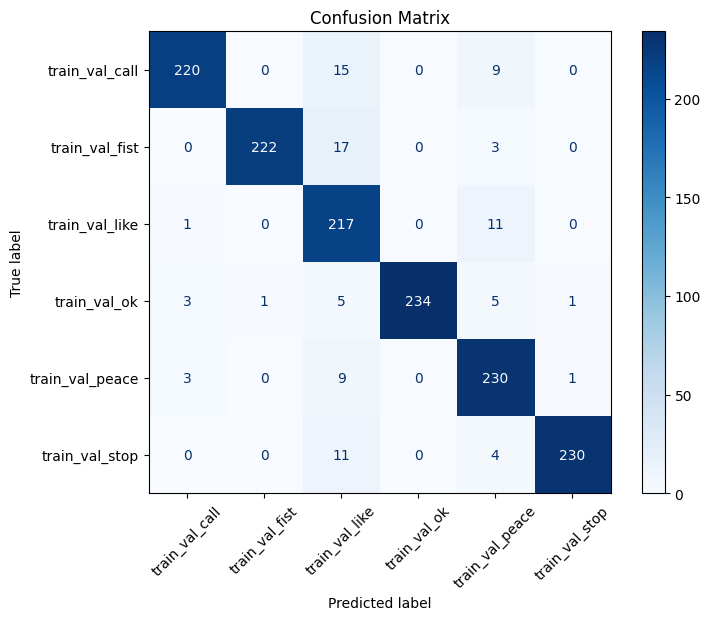

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Ensure model is in evaluation mode
model.eval()

# Forward pass to get predictions
with torch.no_grad():
    outputs = model(X_test_tensor)
    _, predicted = torch.max(outputs, 1)
    predicted = predicted.cpu().numpy()
    y_true = y_test_tensor.cpu().numpy()

# Decode class labels (if label encoder is available)
class_names = le.classes_ if 'le' in globals() else [str(i) for i in np.unique(y_true)]

# Compute confusion matrix
cm = confusion_matrix(y_true, predicted)

# Plot confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, cmap="Blues", xticks_rotation=45)
plt.title("Confusion Matrix")
plt.show()


In [ ]:
train_losses = []
val_losses = []
num_epochs = 50
for epoch in range(num_epochs):
    model.train()
    train_loss = 0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    model.eval()
    val_loss = 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item()

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    scheduler.step(val_loss)

    print(f"Epoch {epoch+1:02d} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")


Epoch 01 | Train Loss: 11.6818 | Val Loss: 2.9926
Epoch 02 | Train Loss: 11.4908 | Val Loss: 3.2759
Epoch 03 | Train Loss: 11.6404 | Val Loss: 3.1696
Epoch 04 | Train Loss: 11.8881 | Val Loss: 3.3714
Epoch 05 | Train Loss: 11.5232 | Val Loss: 3.0607
Epoch 06 | Train Loss: 11.3779 | Val Loss: 3.0020
Epoch 07 | Train Loss: 11.5261 | Val Loss: 3.0361
Epoch 08 | Train Loss: 11.5155 | Val Loss: 2.9750
Epoch 09 | Train Loss: 11.3432 | Val Loss: 2.9487
Epoch 10 | Train Loss: 11.1954 | Val Loss: 2.9327
Epoch 11 | Train Loss: 11.0730 | Val Loss: 2.9118
Epoch 12 | Train Loss: 11.1808 | Val Loss: 3.0059
Epoch 13 | Train Loss: 11.0577 | Val Loss: 2.9591
Epoch 14 | Train Loss: 11.0309 | Val Loss: 3.0441
Epoch 15 | Train Loss: 11.3425 | Val Loss: 2.9942
Epoch 16 | Train Loss: 11.0680 | Val Loss: 2.9804
Epoch 17 | Train Loss: 11.0408 | Val Loss: 3.0119
Epoch 18 | Train Loss: 11.0022 | Val Loss: 2.9683
Epoch 19 | Train Loss: 11.0343 | Val Loss: 2.9492
Epoch 20 | Train Loss: 11.0564 | Val Loss: 2.9848


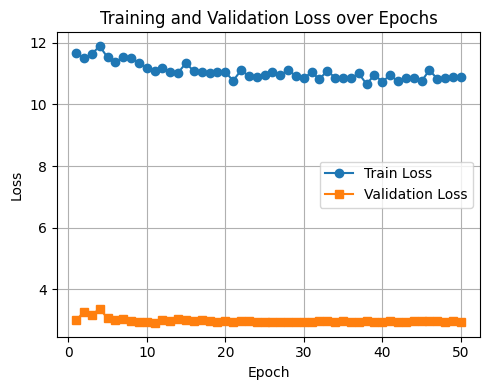

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(5, 4))
plt.plot(range(1, len(train_losses)+1), train_losses, label='Train Loss', marker='o')
plt.plot(range(1, len(val_losses)+1), val_losses, label='Validation Loss', marker='s')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss over Epochs')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


#old model shows signs of mild overfitting and confusion between similar classes, especially between:

train_val_call ↔ train_val_like

train_val_fist → train_val_call or like
 Here's why we can say that:
 Signs of Overfitting:
Training loss decreases steadily, but

Validation loss plateaus early (around epoch 10–15) and stays flat.

This suggests the model is continuing to memorize training patterns without improving generalization.

 Class Confusion:
Confusion matrix shows misclassifications like:

call → like: 28 times

like → call: 25 times

fist → like: 15 times

fist → call: 14 times

These patterns suggest the model is struggling to distinguish between visually similar gestures, especially when:

Hand pose overlaps (e.g., similar finger positions)
What the Model Might Be Doing:
Memorizing positional patterns rather than learning generalized features.

Struggling with intra-class variability (same gesture looking different under lighting/angle changes).

Possibly underutilizing temporal/spatial relationships if the landmark features are not normalized or structured properly.




#Performance under image conditions

In [ ]:
# predictions: DataFrame with filename, true_label, pred_label
import pandas as pd
df_preds = pd.read_csv('/content/drive/MyDrive/improvedmodel/images_conditions.csv')


In [ ]:
print(df_preds.columns)

Index(['filename', 'brightness', 'entropy', 'occlusion', 'brightness_level',
       'entropy_level'],
      dtype='object')


#MERGING TRUE LABELS WITH IMAGE CONDITION

In [ ]:
#MERGING TRUE LABELS WITH IMAGE CONDITION
import os
import json
import pandas as pd

ann_folder = "/content/drive/MyDrive/hgr/hagriddataset/hagrid-sample-30k-384p/ann_train_val"

# Load all labels
true_labels = {}

# Go through each JSON file (each file represents a class)
for json_file in os.listdir(ann_folder):
    if json_file.endswith(".json"):
        label_name = json_file.replace(".json", "")  # e.g., "call"
        json_path = os.path.join(ann_folder, json_file)

        with open(json_path, 'r') as f:
            data = json.load(f)
            for filename in data.keys():
                true_labels[filename] = label_name

print(f"Loaded labels for {len(true_labels)} images.")

# Load your condition CSV
df = pd.read_csv("/content/drive/MyDrive/improvedmodel/images_conditions.csv")

# Map true labels into a new column
df["true_label"] = df["filename"].map(true_labels)

# Save the updated CSV
df.to_csv("final_image_conditions_with_labels.csv", index=False)
print("Saved labeled CSV: image_conditions_with_labels.csv")


Loaded labels for 167943 images.
Saved labeled CSV: image_conditions_with_labels.csv


#MAPPING THE CONDITON WITH TURE LABEL

In [ ]:
# Extract UUID (filename without folder and extension)
df["uuid"] = df["filename"].apply(lambda x: os.path.splitext(os.path.basename(x))[0])

# Now map using UUIDs
df["true_label"] = df["uuid"].map(true_labels)

# Optional: drop uuid column after use
df.drop(columns=["uuid"], inplace=True)

# Save
df.to_csv("/content/final_merged_image_conditions_with_labels.csv", index=False)
print(" Merged successfully. Check 'true_label' column.")



 Merged successfully. Check 'true_label' column.


#X_FEATURE GENERATION FROM EXTRACTED FEATURES

In [ ]:
import os
import cv2
import pandas as pd
import mediapipe as mp
from tqdm import tqdm

# Paths
image_root = "/content/drive/MyDrive/hgr/hagriddataset/hagrid-sample-30k-384p/hagrid_30k"
output_csv = "X_test_features.csv"

# MediaPipe Hands
mp_hands = mp.solutions.hands
hands = mp_hands.Hands(static_image_mode=True)

# Store features
data = []

# Traverse image folders
for root, _, files in os.walk(image_root):
    for file in tqdm(files):
        if file.lower().endswith((".jpg", ".jpeg", ".png")):
            image_path = os.path.join(root, file)
            image = cv2.imread(image_path)
            if image is None:
                continue

            # Resize and convert
            image_rgb = cv2.cvtColor(cv2.resize(image, (224, 224)), cv2.COLOR_BGR2RGB)
            results = hands.process(image_rgb)

            # If no landmarks detected, skip
            if not results.multi_hand_landmarks:
                continue

            # Use first hand detected
            landmarks = results.multi_hand_landmarks[0].landmark
            features = []
            for lm in landmarks:
                features.extend([lm.x, lm.y, lm.z])  # 21 * 3 = 63 features

            # Save filename + features
            rel_path = os.path.relpath(image_path, image_root)
            row = [rel_path] + features
            data.append(row)

# Create DataFrame
columns = ["filename"] + [f"f{i}" for i in range(63)]
df = pd.DataFrame(data, columns=columns)

# Save to CSV
df.to_csv(output_csv, index=False)
print(f" Saved {len(df)} feature rows to {output_csv}")


#MODEL DEFINATION

In [ ]:
class GestureNet(nn.Module):
    def __init__(self, num_classes, dropout_rate=0.4):
        super(GestureNet, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(63, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(dropout_rate),

            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(dropout_rate),

            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        return self.net(x)



#PREDICTION WITH IMAGE CONDITION

In [ ]:
import torch
import pandas as pd

# 1. Load your feature data
features_df = pd.read_csv("/content/drive/MyDrive/improvedmodel/X_test_features.csv")
X = features_df.drop(columns=["filename"]).values
filenames = features_df["filename"].values

# 2. Convert to tensor
X_tensor = torch.tensor(X, dtype=torch.float32)

# 3. Load trained model
model = GestureNet(num_classes=6)  # adjust if your class count is different
model.load_state_dict(torch.load("/content/drive/MyDrive/final_model/newaugnorm_model.pth", map_location='cpu'))
model.eval()

# 4. Run prediction
with torch.no_grad():
    outputs = model(X_tensor)
    pred_indices = torch.argmax(outputs, dim=1).numpy()

# 5. Define label mapping
idx2label = {
    0: 'call',
    1: 'fist',
    2: 'like',
    3: 'ok',
    4: 'peace',
    5: 'stop'
}
pred_labels = [idx2label[idx] for idx in pred_indices]

# 6. Load image condition CSV
conditions_df = pd.read_csv("/content/drive/MyDrive/improvedmodel/images_conditions.csv")

# 7. Merge predictions with condition metadata
# Ensure matching formats for merging
merged_df = pd.DataFrame({
    "filename": filenames,
    "pred_label": pred_labels
})
result_df = pd.merge(conditions_df, merged_df, on="filename", how="inner")

# 8. Save final prediction table
result_df.to_csv("final_predictions_with_conditions.csv", index=False)
print(" Saved prediction table with image conditions to predictions_with_conditions.csv")


 Saved prediction table with image conditions to predictions_with_conditions.csv


In [ ]:
import pandas as pd

# Load image condition metadata
condition_df = pd.read_csv("/content/drive/MyDrive/final_model/final_merged_image_conditions_with_labels.csv")

# Load feature data with filenames and predictions
features_df = pd.read_csv("/content/drive/MyDrive/improvedmodel/X_test_features.csv")

# Assume pred_labels was generated earlier and matches features_df
# Example: pred_labels = ["call", "like", "fist", ...] — same length/order as features_df

# Add predictions to features dataframe
features_df["pred_label"] = pred_labels

# Merge on 'filename'
merged_df = condition_df.merge(features_df[["filename", "pred_label"]], on="filename", how="left")

# Save result
merged_df.to_csv("final_image_conditions_with_labels_predictions.csv", index=False)
print(" Merged predictions into image_conditions_with_predictions.csv")


 Merged predictions into image_conditions_with_predictions.csv


In [ ]:
import pandas as pd
from sklearn.metrics import classification_report
df = pd.read_csv("/content/final_image_conditions_with_labels_predictions.csv")
df = df.dropna(subset=["true_label", "pred_label"])

# Convert labels to strings
df["true_label"] = df["true_label"].astype(str)
df["pred_label"] = df["pred_label"].astype(str)
print(" Overall Classification Report:")
print(classification_report(df["true_label"], df["pred_label"]))

 Overall Classification Report:
              precision    recall  f1-score   support

        call       0.95      0.87      0.91      1536
        fist       0.96      0.88      0.92      1505
        like       0.79      0.93      0.85      1431
          ok       0.99      0.92      0.95      1629
       peace       0.85      0.94      0.89      1529
        stop       0.95      0.92      0.94      1599

    accuracy                           0.91      9229
   macro avg       0.92      0.91      0.91      9229
weighted avg       0.92      0.91      0.91      9229



#OVERALL CLASSIFICATION REPORT

In [ ]:
def evaluate_by_condition(df, condition_col):
    from sklearn.metrics import classification_report
    condition_values = df[condition_col].unique()

    for condition in condition_values:
        subset = df[df[condition_col] == condition]
        print(f"\nClassification Report for {condition_col} = {condition} ({len(subset)} samples):")
        print(classification_report(subset["true_label"], subset["pred_label"]))

# Example: Evaluate by brightness, entropy and occlusion
evaluate_by_condition(df, "brightness_level")
evaluate_by_condition(df, "entropy_level")
evaluate_by_condition(df, "occlusion")



Classification Report for brightness_level = Low (2975 samples):
              precision    recall  f1-score   support

        call       0.95      0.84      0.89       511
        fist       0.96      0.88      0.92       466
        like       0.80      0.93      0.86       456
          ok       0.99      0.91      0.95       525
       peace       0.83      0.95      0.89       512
        stop       0.94      0.93      0.94       505

    accuracy                           0.91      2975
   macro avg       0.91      0.91      0.91      2975
weighted avg       0.91      0.91      0.91      2975


Classification Report for brightness_level = High (3180 samples):
              precision    recall  f1-score   support

        call       0.96      0.89      0.92       534
        fist       0.96      0.89      0.92       525
        like       0.78      0.94      0.85       497
          ok       0.99      0.93      0.96       585
       peace       0.89      0.94      0.92       509

#CONFUSION MATRIX

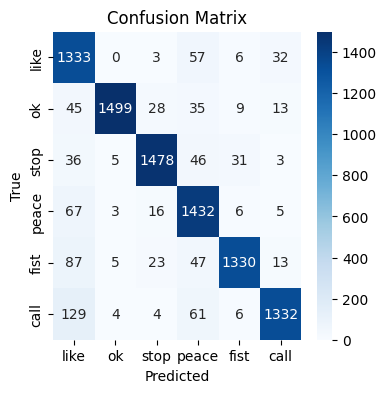

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(df["true_label"], df["pred_label"], labels=df["true_label"].unique())
plt.figure(figsize=(4,4))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=df["true_label"].unique(), yticklabels=df["true_label"].unique(), cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()


In [ ]:
y_probs = model(torch.tensor(X_test).float().to(device)).detach().cpu().numpy()


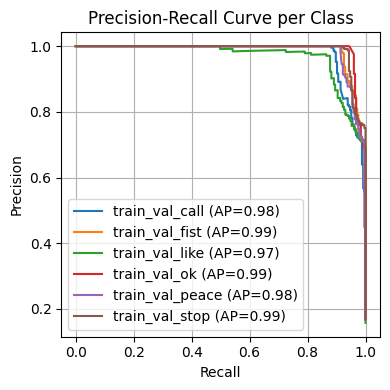

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import label_binarize
from sklearn.metrics import precision_recall_curve, average_precision_score
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader

# Assume: you already have your trained model, test_loader, and label encoder (le)

# --- Step 1: Collect true labels and predicted probabilities ---
model.eval()
y_true = []
y_probs = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        probs = F.softmax(outputs, dim=1).cpu().numpy()

        y_probs.append(probs)
        y_true.extend(labels.cpu().numpy())

# Convert to final arrays
y_probs = np.vstack(y_probs)                     # shape: (n_samples, n_classes)
y_true = np.array(y_true)                        # shape: (n_samples,)
classes = le.inverse_transform(np.arange(y_probs.shape[1]))  # class names from label encoder

# --- Step 2: Binarize true labels ---
y_true_bin = label_binarize(y_true, classes=np.arange(len(classes)))  # one-hot encoding

# --- Step 3: Plot Precision-Recall Curves ---
plt.figure(figsize=(4,4))
for i in range(len(classes)):
    precision, recall, _ = precision_recall_curve(y_true_bin[:, i], y_probs[:, i])
    ap = average_precision_score(y_true_bin[:, i], y_probs[:, i])
    plt.plot(recall, precision, label=f"{classes[i]} (AP={ap:.2f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve per Class")
plt.legend(loc="best")
plt.grid(True)
plt.tight_layout()
plt.show()


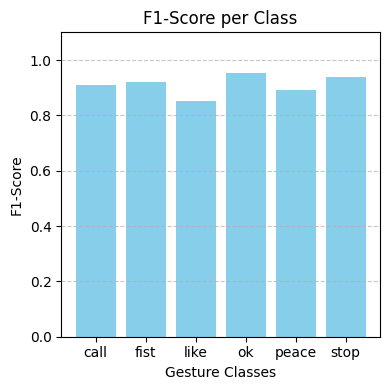

In [ ]:
from sklearn.metrics import f1_score
import matplotlib.pyplot as plt
import numpy as np

# True and predicted labels (as class names or integers)
y_true = df["true_label"].values
y_pred = df["pred_label"].values
classes = np.unique(y_true)

# Compute F1-score for each class
f1_scores = f1_score(y_true, y_pred, average=None, labels=classes)

# Plot
plt.figure(figsize=(4, 4))
plt.bar(classes, f1_scores, color='skyblue')
plt.ylim(0, 1.1)
plt.xlabel("Gesture Classes")
plt.ylabel("F1-Score")
plt.title("F1-Score per Class")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()


#PERFORMANCE OF EACH CONDITION

In [ ]:
import pandas as pd
from sklearn.metrics import accuracy_score

# Define the condition columns you want to analyze
condition_columns = ["brightness_level", "entropy_level", "occlusion"]

# Store performance results
results = []

for col in condition_columns:
    print(f"\n Evaluating by: {col}")
    for value in df[col].unique():
        subset = df[df[col] == value]
        acc = accuracy_score(subset["true_label"], subset["pred_label"])
        print(f"  {col} = {value}: Accuracy = {acc:.4f}")
        results.append({
            "Condition": col,
            "Value": value,
            "Accuracy": acc,
            "Samples": len(subset)
        })

# Convert results to a DataFrame
results_df = pd.DataFrame(results)

# Find best performing value per condition
best_performance = results_df.loc[results_df.groupby("Condition")["Accuracy"].idxmax()]

print("\n Best Performance per Condition:")
print(best_performance)



 Evaluating by: brightness_level
  brightness_level = Low: Accuracy = 0.9076
  brightness_level = High: Accuracy = 0.9195
  brightness_level = Medium: Accuracy = 0.9044

 Evaluating by: entropy_level
  entropy_level = Medium: Accuracy = 0.9090
  entropy_level = High: Accuracy = 0.8930
  entropy_level = Low: Accuracy = 0.9294

 Evaluating by: occlusion
  occlusion = clear: Accuracy = 0.9106

 Best Performance per Condition:
          Condition  Value  Accuracy  Samples
1  brightness_level   High  0.919497     3180
5     entropy_level    Low  0.929351     3114
6         occlusion  clear  0.910608     9229


In [ ]:
results_df.to_csv("final_condition_wise_accuracy.csv", index=False)


In [ ]:
import pandas as pd
from sklearn.metrics import accuracy_score
from itertools import product

# Define the condition levels
brightness_levels = df['brightness_level'].unique()
occlusion_levels = df['occlusion'].unique()

results = []

# Loop over all combinations
for b_level, o_level in product(brightness_levels, occlusion_levels):
    subset = df[(df['brightness_level'] == b_level) & (df['occlusion'] == o_level)]

    if not subset.empty:
        acc = accuracy_score(subset['true_label'], subset['pred_label'])
        results.append({
            'brightness_level': b_level,
            'occlusion_level': o_level,
            'num_samples': len(subset),
            'accuracy': round(acc * 100, 2)
        })

# Convert results to a DataFrame
results_df = pd.DataFrame(results).sort_values(by='accuracy', ascending=False)
print(results_df)


  brightness_level occlusion_level  num_samples  accuracy
1             High           clear         3180     91.95
0              Low           clear         2975     90.76
2           Medium           clear         3074     90.44


#OUTPUT TESTING

In [ ]:
brightness_bins = [85, 170]
entropy_bins = [3.5, 6.5]
occlusion_bins = [0.02, 0.05]
labels = ['low', 'medium', 'high']

def classify_condition(value, bins, labels):
    return labels[np.digitize([value], bins)[0] - 1]

def extract_landmarks(image):
    with mp.solutions.hands.Hands(static_image_mode=True) as hands:
        results = hands.process(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
        if results.multi_hand_landmarks:
            lm = results.multi_hand_landmarks[0]
            return np.array([[p.x, p.y, p.z] for p in lm.landmark]).flatten()
        return None

def estimate_conditions(image, landmarks):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    brightness = np.mean(cv2.cvtColor(image, cv2.COLOR_BGR2HSV)[:, :, 2])
    entropy = shannon_entropy(gray)
    occlusion = 1.0 if landmarks is None else np.std(np.linalg.norm(landmarks.reshape(-1, 3) - landmarks[:3], axis=1))

    return (
        classify_condition(brightness, brightness_bins, labels),
        classify_condition(entropy, entropy_bins, labels),
        classify_condition(occlusion, occlusion_bins, labels)
    )


In [ ]:
from skimage.measure import shannon_entropy
while True:
    print("Click 'Capture' to take a photo...")
    frame = capture_image()

    landmarks = extract_landmarks(frame)
    if landmarks is not None:
        input_tensor = torch.tensor(landmarks, dtype=torch.float32).unsqueeze(0).to(device)
        with torch.no_grad():
            output = model(input_tensor)
            gesture = le.inverse_transform([torch.argmax(output).item()])[0]
    else:
        gesture = "No hand detected"

    brightness, entropy, occlusion = estimate_conditions(frame, landmarks)

    print("\n Gesture:", gesture)
    print(" Brightness:", brightness)
    print(" Entropy   :", entropy)
    print(" Occlusion :", occlusion)

    again = input("\nPress Enter to continue or type 'q' to quit: ")
    if again.lower() == 'q':
        break


Click 'Capture' to take a photo...

 Gesture: No hand detected
 Brightness: high
 Entropy   : medium
 Occlusion : medium

Press Enter to continue or type 'q' to quit: 
Click 'Capture' to take a photo...

 Gesture: train_val_stop
 Brightness: high
 Entropy   : medium
 Occlusion : medium

Press Enter to continue or type 'q' to quit: 
Click 'Capture' to take a photo...

 Gesture: No hand detected
 Brightness: low
 Entropy   : medium
 Occlusion : medium

Press Enter to continue or type 'q' to quit: 
Click 'Capture' to take a photo...

 Gesture: train_val_stop
 Brightness: high
 Entropy   : medium
 Occlusion : medium

Press Enter to continue or type 'q' to quit: 
Click 'Capture' to take a photo...

 Gesture: train_val_ok
 Brightness: high
 Entropy   : medium
 Occlusion : medium

Press Enter to continue or type 'q' to quit: 
Click 'Capture' to take a photo...

 Gesture: No hand detected
 Brightness: high
 Entropy   : medium
 Occlusion : medium

Press Enter to continue or type 'q' to quit: 
C

In [ ]:
def estimate_conditions(frame, landmarks):
    # Convert frame to grayscale
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    # Estimate brightness as the average pixel intensity
    brightness = np.mean(gray)

    # Estimate entropy
    entropy = shannon_entropy(gray)

    # Estimate occlusion as the number of missing landmarks
    if landmarks is not None:
        occlusion = sum(1 for val in landmarks if val == 0 or val is None)
    else:
        occlusion = 21  # Assume fully occluded if no hand detected

    return brightness, entropy, occlusion


In [ ]:
import torch.nn.functional as F
from skimage.measure import shannon_entropy
import cv2

BRIGHTNESS_THRESHOLD = 70
CONFIDENCE_THRESHOLD = 0.6

while True:
    print("\nClick 'Capture' to take a photo...")
    frame = capture_image()

    landmarks = extract_landmarks(frame)

    if landmarks is not None:
        input_tensor = torch.tensor(landmarks, dtype=torch.float32).unsqueeze(0).to(device)
        with torch.no_grad():
            output = model(input_tensor)
            probs = F.softmax(output, dim=1)
            conf, pred_class = torch.max(probs, 1)
            gesture = le.inverse_transform([pred_class.item()])[0]
            confidence = conf.item()
    else:
        gesture = "No hand detected"
        confidence = 0.0

    # Estimate image conditions
    brightness, entropy, occlusion = estimate_conditions(frame, landmarks)

    # Feedback to user
    print("\nGesture:", gesture)
    print("Confidence: {:.2f}".format(confidence))

    try:
        print("Brightness:", round(float(brightness), 2))
        print("Entropy   :", round(float(entropy), 2))
        print("Occlusion :", round(float(occlusion), 2))

        if brightness < BRIGHTNESS_THRESHOLD:
            print("⚠️  Please move to a well-lit area (brightness too low).")

        if confidence < CONFIDENCE_THRESHOLD:
            print("⚠️  Prediction confidence is low. Try adjusting your hand position or lighting.")

    except Exception as e:
        print("⚠️  Error processing image conditions:", e)

    again = input("\nPress Enter to continue or type 'q' to quit: ")
    if again.lower() == 'q':
        break



Click 'Capture' to take a photo...

Gesture: No hand detected
Confidence: 0.00
Brightness: 79.67
Entropy   : 6.87
Occlusion : 21.0
⚠️  Prediction confidence is low. Try adjusting your hand position or lighting.

Press Enter to continue or type 'q' to quit: 

Click 'Capture' to take a photo...

Gesture: train_val_stop
Confidence: 1.00
Brightness: 71.46
Entropy   : 6.8
Occlusion : 0.0

Press Enter to continue or type 'q' to quit: q


In [ ]:
import torch.nn.functional as F
from skimage.measure import shannon_entropy
import cv2
import torch
import numpy as np

BRIGHTNESS_THRESHOLD = 70
CONFIDENCE_THRESHOLD = 0.6
ENTROPY_THRESHOLD = 4.0
OCCLUSION_THRESHOLD = 0.3  # adjust based on bounding box area ratio

def estimate_conditions(image, landmarks):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    brightness = np.mean(gray)
    entropy = shannon_entropy(gray)

    # Occlusion: estimate based on how many landmarks are missing
    if landmarks is not None:
        occlusion = np.count_nonzero(np.array(landmarks) == 0) / len(landmarks)
    else:
        occlusion = 1.0

    return brightness, entropy, occlusion

while True:
    print("\nClick 'Capture' to take a photo...")
    frame = capture_image()

    landmarks = extract_landmarks(frame)

    if landmarks is not None:
        input_tensor = torch.tensor(landmarks, dtype=torch.float32).unsqueeze(0).to(device)

        with torch.no_grad():
            output = model(input_tensor)
            probs = F.softmax(output, dim=1)
            conf, pred_class = torch.max(probs, 1)
            gesture = le.inverse_transform([pred_class.item()])[0]
            confidence = conf.item()
    else:
        gesture = "No hand detected"
        confidence = 0.0

    # Estimate image quality conditions
    try:
        brightness, entropy, occlusion = estimate_conditions(frame, landmarks)
    except Exception as e:
        brightness, entropy, occlusion = 0, 0, 1
        print(f"  Error estimating image quality: {e}")

    # Display results
    print("\n====================")
    print("  Gesture      :", gesture)
    print(" Confidence   : {:.2f}".format(confidence))
    print(" Brightness   :", round(brightness, 2))
    print(" Entropy      :", round(entropy, 2))
    print(" Occlusion    :", round(occlusion, 2))
    print("====================")

    # Quality feedback
    if gesture == "No hand detected":
        print(" No hand detected. Please place your hand inside the frame.")
    else:
        if brightness < BRIGHTNESS_THRESHOLD:
            print("  Please move to a well-lit area (brightness too low).")
        if entropy < ENTROPY_THRESHOLD:
            print("  Image appears blurry or lacks detail. Try holding your hand steady.")
        if occlusion > OCCLUSION_THRESHOLD:
            print("  Hand landmarks partially missing. Ensure the full hand is visible.")
        if confidence < CONFIDENCE_THRESHOLD:
            print("  Prediction confidence is low. Try adjusting your hand or lighting.")

    again = input("\n Press Enter to try again or type 'q' to quit: ")
    if again.lower() == 'q':
        break



Click 'Capture' to take a photo...

  Gesture      : train_val_like
 Confidence   : 1.00
 Brightness   : 59.39
 Entropy      : 6.3
 Occlusion    : 0.0
  Please move to a well-lit area (brightness too low).

 Press Enter to try again or type 'q' to quit: 

Click 'Capture' to take a photo...

  Gesture      : train_val_peace
 Confidence   : 1.00
 Brightness   : 65.44
 Entropy      : 6.4
 Occlusion    : 0.0
  Please move to a well-lit area (brightness too low).

 Press Enter to try again or type 'q' to quit: 

Click 'Capture' to take a photo...

  Gesture      : train_val_call
 Confidence   : 0.97
 Brightness   : 125.69
 Entropy      : 7.15
 Occlusion    : 0.0

 Press Enter to try again or type 'q' to quit: 

Click 'Capture' to take a photo...

  Gesture      : train_val_stop
 Confidence   : 0.99
 Brightness   : 116.35
 Entropy      : 7.21
 Occlusion    : 0.0

 Press Enter to try again or type 'q' to quit: 

Click 'Capture' to take a photo...

  Gesture      : train_val_like
 Confidence 